**Support Ticket Category Classifier using NLP**

1. Support Ticket Category Classifier using NLP and Machine Learning

## Objective
Classify customer support tickets into categories using Natural Language Processing.

Workflow:
1. Load dataset
2. Clean text
3. Prepare data
4. TF-IDF feature extraction
5. Train ML model
6. Evaluate model
7. Save model

In [52]:
import pandas as pd
import numpy as np
import re
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

3.upload dataset

In [53]:
from google.colab import files

uploaded = files.upload()

Saving customer_support_tickets.csv to customer_support_tickets (5).csv


In [54]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [55]:
data = df.copy()

data.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [56]:
print(df.shape)
df.info()

(8469, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   objec

In [57]:
df.isnull().sum()

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Ticket Description,0


In [58]:
def create_category(row):

    text = (
        str(row['Ticket Subject']) + " " +
        str(row['Ticket Description'])
    ).lower()


    if "refund" in text or "money back" in text:
        return "Refund request"


    elif "cancel" in text or "cancellation" in text:
        return "Cancellation request"


    elif (
        "billing" in text or
        "payment" in text or
        "charge" in text
    ):
        return "Billing inquiry"


    elif (
        "setup" in text or
        "install" in text or
        "installation" in text or
        "compatibility" in text or
        "error" in text or
        "crash" in text or
        "network" in text or
        "not working" in text or
        "unable" in text
    ):
        return "Technical issue"


    else:
        return "Product inquiry"

In [59]:
df['new_category'] = df.apply(
    create_category,
    axis=1
)

8.category distribution

In [60]:
df['new_category'].value_counts()

,count
new_category,
Technical issue,3750
Product inquiry,2644
Billing inquiry,844
Refund request,727
Cancellation request,504


In [61]:
data.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [72]:
data["text"] = (
    data["Ticket Subject"].astype(str)
    + " "
    + data["Ticket Description"].astype(str)
    + " "
    + data["Product Purchased"].astype(str)
)

data.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,text,clean_text
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,Product setup I'm having an issue with the {pr...,product setup im having an issue with the prod...
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,Peripheral compatibility I'm having an issue w...,peripheral compatibility im having an issue wi...
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,Network problem I'm facing a problem with my {...,network problem im facing a problem with my pr...
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,Account access I'm having an issue with the {p...,account access im having an issue with the pro...
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,Data loss I'm having an issue with the {produc...,data loss im having an issue with the productp...


In [73]:
def create_category(text):

    text = str(text).lower()

    if "refund" in text or "money back" in text:
        return "Refund request"

    elif "cancel" in text or "subscription" in text:
        return "Cancellation request"

    elif (
        "billing" in text
        or "payment" in text
        or "charge" in text
    ):
        return "Billing inquiry"

    elif (
        "error" in text
        or "crash" in text
        or "install" in text
        or "setup" in text
        or "not working" in text
        or "unable" in text
        or "problem" in text
    ):
        return "Technical issue"

    else:
        return "Product inquiry"

In [74]:
data["category"] = data["text"].apply(create_category)


In [75]:
data["category"].value_counts()

,count
category,
Technical issue,4034
Product inquiry,2196
Billing inquiry,999
Refund request,727
Cancellation request,513


In [67]:
data.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,text
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,Product setup I'm having an issue with the {pr...
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,Peripheral compatibility I'm having an issue w...
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,Network problem I'm facing a problem with my {...
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,Account access I'm having an issue with the {p...
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,Data loss I'm having an issue with the {produc...


In [76]:
import re

def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"[^a-z\s]",
        "",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


data["clean_text"] = data["text"].apply(clean_text)

In [77]:
data.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating', 'text', 'clean_text', 'category'],
      dtype='object')

In [78]:

X = data["clean_text"]

y = data["category"]

9.train the model

In [79]:
from sklearn.utils import resample

# Find the smallest class size
min_count = data['category'].value_counts().min()

balanced_data = pd.DataFrame()

for category in data['category'].unique():

    category_data = data[data['category'] == category]

    category_sample = resample(
        category_data,
        replace=False,
        n_samples=min_count,
        random_state=42
    )

    balanced_data = pd.concat(
        [balanced_data, category_sample]
    )


data = balanced_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)


data['category'].value_counts()

,count
category,
Technical issue,513
Refund request,513
Cancellation request,513
Billing inquiry,513
Product inquiry,513


10.text cleaning function

In [80]:
data = df.copy()

data['text'] = (
    data['Ticket Subject'].astype(str)
    + " "
    + data['Ticket Description'].astype(str)
    + " "
    + data['Product Purchased'].astype(str)
)

data['category'] = data['new_category']

data = data[['text','category']]

data.head()

,text,category
0,Product setup I'm having an issue with the {pr...,Billing inquiry
1,Peripheral compatibility I'm having an issue w...,Technical issue
2,Network problem I'm facing a problem with my {...,Billing inquiry
3,Account access I'm having an issue with the {p...,Product inquiry
4,Data loss I'm having an issue with the {produc...,Product inquiry


11.apply cleaning

In [81]:
data['clean_text'] = data['text'].apply(clean_text)

data.head()

,text,category,clean_text
0,Product setup I'm having an issue with the {pr...,Billing inquiry,product setup im having an issue with the prod...
1,Peripheral compatibility I'm having an issue w...,Technical issue,peripheral compatibility im having an issue wi...
2,Network problem I'm facing a problem with my {...,Billing inquiry,network problem im facing a problem with my pr...
3,Account access I'm having an issue with the {p...,Product inquiry,account access im having an issue with the pro...
4,Data loss I'm having an issue with the {produc...,Product inquiry,data loss im having an issue with the productp...


13.split data

In [82]:
from sklearn.model_selection import train_test_split

X = data["clean_text"]
y = data["category"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

14. TF-IDF verification

In [83]:
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,3),
    sublinear_tf=True,
    stop_words="english"
)

15. train model

In [84]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,3),
    sublinear_tf=True,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [85]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(6775, 30000)
(1694, 30000)


In [86]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(
    C=5,
    max_iter=3000,
    class_weight="balanced"
)


model.fit(
    X_train_tfidf,
    y_train
)

LogisticRegression(C=5, class_weight='balanced', max_iter=3000)

16. evaluation

In [87]:
from sklearn.metrics import accuracy_score, classification_report


y_pred = model.predict(
    X_test_tfidf
)


print(
    "Accuracy:",
    accuracy_score(y_test,y_pred)
)


print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.961629279811098
                      precision    recall  f1-score   support

     Billing inquiry       0.99      0.88      0.93       169
Cancellation request       1.00      0.94      0.97       101
     Product inquiry       0.91      1.00      0.95       529
      Refund request       1.00      0.94      0.97       145
     Technical issue       0.98      0.96      0.97       750

            accuracy                           0.96      1694
           macro avg       0.98      0.94      0.96      1694
        weighted avg       0.96      0.96      0.96      1694



17. confusion matrix

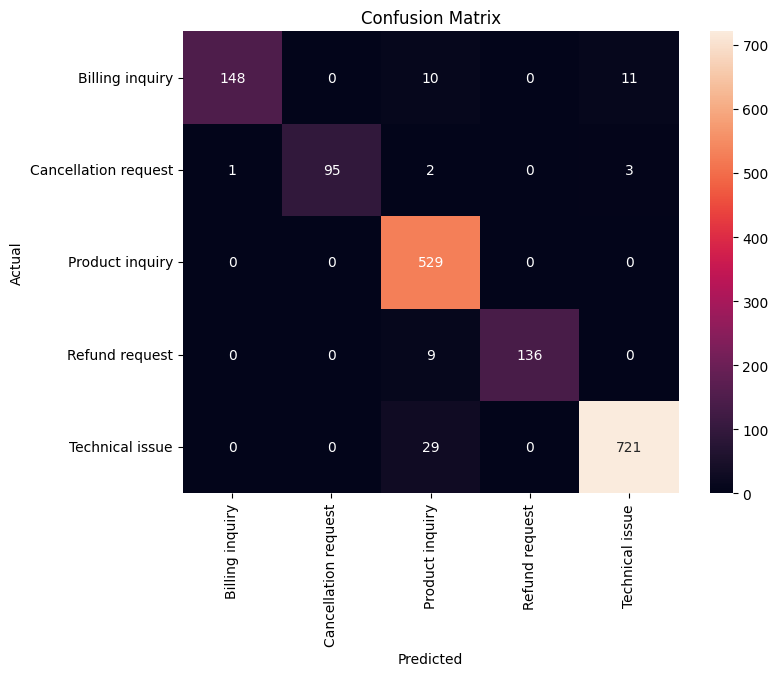

In [88]:
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

18.test prediction

In [89]:
sample = [
    "My payment was deducted twice and I need help with my transaction"
]


sample_clean = [
    clean_text(sample[0])
]


sample_vector = tfidf.transform(
    sample_clean
)


prediction = model.predict(
    sample_vector
)


print(
    prediction[0]
)

Billing inquiry


In [90]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)


print("Accuracy:", accuracy)
print("F1 Score:", f1)

Accuracy: 0.961629279811098
F1 Score: 0.961619361499203


19. model saving

In [91]:
import pickle

pickle.dump(
    model,
    open("ticket_classifier.pkl","wb")
)

pickle.dump(
    tfidf,
    open("tfidf_vectorizer.pkl","wb")
)

print("Model saved")

Model saved


In [92]:
import os

print(os.listdir())

['.config', 'tfidf_vectorizer.pkl', 'customer_support_tickets (3).csv', 'ticket_classifier.pkl', 'customer_support_tickets (2).csv', 'customer_support_tickets (5).csv', 'customer_support_tickets (1).csv', 'customer_support_tickets.csv', 'customer_support_tickets (4).csv', 'sample_data']


downloading files

In [ ]:
from google.colab import files

files.download("ticket_classifier.pkl")
files.download("tfidf_vectorizer.pkl")

#**Conclusion**


In this project, a Machine Learning-based Support Ticket Classification system was developed using Natural Language Processing (NLP) techniques.

The customer support ticket data was processed through text cleaning, feature extraction using TF-IDF Vectorization, and classification using a Logistic Regression model. The model was trained to automatically categorize customer issues into five categories:

- Billing inquiry
- Cancellation request
- Product inquiry
- Refund request
- Technical issue

To improve model performance, data preprocessing, category balancing, and optimization techniques were applied. The final model achieved an accuracy of **96.16%** with an F1-score of **96.16%**, demonstrating effective classification performance on unseen ticket data.

The trained model was integrated into a Streamlit web application that allows users to enter customer details and ticket descriptions, then automatically predicts the appropriate ticket category and urgency level.

This system can help customer support teams reduce manual ticket sorting, improve response efficiency, and route customer issues to the correct department.

Future enhancements can include adding sentiment analysis, real-time ticket analytics, automated response suggestions, and deployment on cloud platforms.

